In [1]:
# --- Repro (safe, minimal) ---
import os, random, numpy as np, torch
SEED = 12345
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.set_num_threads(1)


In [2]:
# --- Path plumbing (point to src) + autoreload ---
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

NB   = Path.cwd()
ROOT = NB.parent
SRC  = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.append(str(SRC))

from data_pipeline.config import ROOT as ROOT_CFG, PROCESSED_DIR, CLEANED
print("CWD:", NB)
print("SRC:", SRC)
print("ROOT:", ROOT_CFG)
print("PROC:", PROCESSED_DIR)
print("CLEANED:", CLEANED)


# --- 0) Imports & paths ---
from pathlib import Path
import numpy as np

from simulator.env import HedgingEnv
from simulator.rewards import pnl_only
from rl_agent.policy_nn import PolicyNetwork, PolicyConfig
from rl_agent.trainer import train_reinforce, TrainConfig, evaluate_env
from simulator.baselines import volatility_targeting, momentum_policy, delta_hedge_policy

CWD: /Users/ya/Desktop/deep-hedging-rl/notebooks
SRC: /Users/ya/Desktop/deep-hedging-rl/src
ROOT: /Users/ya/Desktop/deep-hedging-rl
PROC: /Users/ya/Desktop/deep-hedging-rl/data/processed
CLEANED: /Users/ya/Desktop/deep-hedging-rl/data/processed/cleaned


In [3]:
# --- 1) Load panel exported from 02_simulator ---
panel = pd.read_csv(CLEANED / "hedging_panel_spx.csv", parse_dates=["date"])
panel = panel.sort_values("date").reset_index(drop=True)

print("Panel window:", panel["date"].min(), "→", panel["date"].max())
print("Columns:", list(panel.columns)[:12], "...")

Panel window: 2005-01-21 00:00:00 → 2023-08-31 00:00:00
Columns: ['date', 'close_spy', 'vix', 'rate_10y', 'hvol_10d', 'hvol_14d', 'hvol_30d', 'hvol_60d', 'hvol_91d', 'hvol_122d', 'hvol_152d', 'hvol_182d'] ...


In [4]:
# Assume `panel` already loaded and has 'date', 'ret_fwd', and your feature columns
panel = panel.sort_values("date").set_index("date")

state_cols = [
    c for c in [
        "iv_atm_30d_spx","iv_ts_slope_spx","iv_skew_30d_spx",
        "vix","rate_10y","rv_21d","hvol_30d","hvol_91d",
        "ret_1d","close_spy_z60"
    ] if c in panel.columns
]
print("STATE_COLS initial:", state_cols)

# 3) Time splits
CUT_TRAIN = "2016-12-31"
CUT_VAL   = "2019-12-31"
train = panel.loc[:CUT_TRAIN].copy()
val   = panel.loc[CUT_TRAIN:].loc[:CUT_VAL].copy()
test  = panel.loc[CUT_VAL:].copy()

if not state_cols:
    raise ValueError("state_cols is empty; please select at least one feature")

std_train = train[state_cols].std(ddof=1)
zero_sd = std_train[std_train <= 1e-8].index.tolist()
if zero_sd:
    print("Dropping near-constant features:", zero_sd)
    state_cols = [c for c in state_cols if c not in zero_sd]
    if not state_cols:
        raise ValueError("All candidate features were near-constant on the train split")
    std_train = train[state_cols].std(ddof=1)

print("STATE_COLS final:", state_cols)
mu = train[state_cols].mean()
sd = std_train.replace(0.0, 1.0).fillna(1.0)


def apply_standardize(df):
    df = df.copy()
    df[state_cols] = (df[state_cols] - mu) / sd
    return df

train_s = apply_standardize(train).dropna(subset=state_cols + ["ret_fwd"])
val_s   = apply_standardize(val).dropna(subset=state_cols + ["ret_fwd"])
test_s  = apply_standardize(test).dropna(subset=state_cols + ["ret_fwd"])

for name, df_ in [("TRAIN*", train_s), ("VAL*", val_s), ("TEST*", test_s)]:
    print(name, df_.index.min().date(), "→", df_.index.max().date(), "| n=", len(df_))


STATE_COLS initial: ['iv_atm_30d_spx', 'iv_ts_slope_spx', 'iv_skew_30d_spx', 'vix', 'rate_10y', 'rv_21d', 'hvol_30d', 'hvol_91d']
STATE_COLS final: ['iv_atm_30d_spx', 'iv_ts_slope_spx', 'iv_skew_30d_spx', 'vix', 'rate_10y', 'rv_21d', 'hvol_30d', 'hvol_91d']
TRAIN* 2005-03-09 → 2016-12-28 | n= 6461
VAL* 2017-01-04 → 2019-12-31 | n= 3273
TEST* 2019-12-31 → 2023-08-31 | n= 7695


In [5]:
from rl_agent.trainer import reward_bps

SEED = 12345

ENV_KW = dict(
    features=state_cols,        # <- name must be 'features'
    reward_fn=reward_bps,       # <- pass your reward function here
    window=45,
    txn_cost_bps=1.0,
    pos_limit=2.0,
    scaler=None,                # optional: leave None unless you have a callable
    rng_seed=SEED,              # <- name must be 'rng_seed'
    hold_on_nan=True
)

env_tr = HedgingEnv(df=train_s, **ENV_KW)
env_va = HedgingEnv(df=val_s,   **ENV_KW)
env_te = HedgingEnv(df=test_s,  **ENV_KW)


In [ ]:
# Infer obs_dim directly from the env's first observation
from simulator.baselines import volatility_targeting, momentum_policy, delta_hedge_policy

obs0 = env_tr.reset()
import numpy as np
obs_dim = int(np.asarray(obs0).reshape(-1).shape[0])
print("obs_dim =", obs_dim)

policy = PolicyNetwork(
    PolicyConfig(
        input_dim=obs_dim,   # <-- IMPORTANT
        hidden=128,
        init_log_std=-0.3,
        device="cpu",
    )
)

train_cfg = TrainConfig(
    gamma=0.99,
    entropy_coef=1e-3,   # reduced entropy bonus once exploration starts
    lr=1e-3,
    max_steps=None,      # consume full episodes for better signal
    max_rollout_steps=250,  # optional cap for quicker experiments
    device="cpu",
    print_every=25,
    normalize_returns=True,
    max_episodes=150,
)


In [ ]:
result = train_reinforce(
    env=env_tr,
    policy=policy,
    cfg=train_cfg,
)

# Normalize return types
if isinstance(result, tuple):
    # (policy, logs) or similar
    if len(result) == 2:
        trained_policy, logs = result
    else:
        trained_policy, logs = result[0], {}
elif isinstance(result, dict):
    # trainer returned only logs; policy was updated in-place
    trained_policy, logs = policy, result
else:
    # trainer returned only the trained policy
    trained_policy, logs = result, {}

history = logs if isinstance(logs, dict) else {}


In [ ]:
# Diagnostics: summarize training history
import pandas as pd

if history:
    episodes = history.get("episode_return", [])
    lengths = history.get("episode_len", [])
    df_hist = pd.DataFrame({
        "episode": np.arange(1, len(episodes) + 1),
        "episode_return": episodes,
        "episode_len": lengths,
    })
    display(df_hist.tail())

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(df_hist["episode"], df_hist["episode_return"], lw=1.0)
    axes[0].set_title("Episode return")
    axes[0].set_xlabel("Episode")
    axes[0].set_ylabel("Return (bp)")

    axes[1].plot(df_hist["episode"], df_hist["episode_len"], lw=1.0, color="tab:orange")
    axes[1].set_title("Episode length")
    axes[1].set_xlabel("Episode")
    axes[1].set_ylabel("Steps")

    eval_sharpes = history.get("eval_sharpe", [])
    if eval_sharpes:
        eval_eps = np.arange(train_cfg.print_every, train_cfg.print_every * len(eval_sharpes) + 1, train_cfg.print_every)
        fig2, ax2 = plt.subplots(figsize=(6, 4))
        ax2.plot(eval_eps, eval_sharpes, marker="o")
        ax2.set_title("Eval Sharpe (deterministic)")
        ax2.set_xlabel("Episode")
        ax2.set_ylabel("Sharpe")
        ax2.axhline(0.0, color="grey", lw=0.8, ls="--")
else:
    print("No training history available (logs empty).")


In [ ]:
trained_policy.eval()
m_tr = evaluate_env(env_tr, trained_policy)
m_va = evaluate_env(env_va, trained_policy)
m_te = evaluate_env(env_te, trained_policy)

print(f"Policy Sharpe T/V/E: {m_tr['sharpe']:.3f} / {m_va['sharpe']:.3f} / {m_te['sharpe']:.3f}")

In [ ]:
#Stop the code here
# --- IGNORE ---
#import sys
#sys.exit(0)
# --- IGNORE ---


# Gae Training for all 

### Actor–Critic (GAE) script run

We replace REINFORCE with a lower-variance Actor–Critic (policy + value head, GAE),
entropy/LR schedules, grad clipping, and checkpoint on best VALID Sharpe.


In [6]:
# --- GAE imports (use your scripts) ---
from rl_agent.train_ac_gae import train as train_gae
from rl_agent.experiment import build_envs, deterministic_rewards
from rl_agent.trainer import evaluate_env

from pathlib import Path
import numpy as np
import json


In [7]:
panel = panel.copy()
panel = panel.reset_index()

In [15]:
# --- Paths for artifacts ---
RUN_DIR = ROOT / "models" / "gae_run1"
CKPT    = RUN_DIR / "best.pt"
CONF    = RUN_DIR / "config.json"
RUN_DIR.mkdir(parents=True, exist_ok=True)

# --- Choose window/hparams (start conservative; you can sweep later) ---
WINDOW = 30
LR     = 5e-4
ENT    = 0.01 # starting entropy bonus
STEPS  = 2500
ENT_FLOOR = 0.01 # final entropy bonus
WEIGHT_DECAY = 1e-4
EARLY_STOP = 300

# --- Train Actor–Critic (GAE) on your current panel & features ---
policy_ac, (tr_ac, va_ac, te_ac), history_ac = train_gae(
    panel=panel,                 # uses the same panel you've prepared above
    state_cols=state_cols,       # same features
    train_end="2017-12-31",
    valid_end="2019-12-31",
    window=WINDOW,
    txn_cost_bps=1.0,
    pos_limit=1.0,
    hidden=256,
    lr=LR,
    steps=STEPS,
    entropy_start=ENT,
    entropy_floor=ENT_FLOOR,
    device="cpu",
    seed=42,
    weight_decay=WEIGHT_DECAY,
    early_stop_patience=EARLY_STOP,
    save_ckpt=str(CKPT),         # saves best VALID Sharpe checkpoint
    save_config=str(CONF),       # saves run config JSON
    save_outdir=str(RUN_DIR),    # saves results.json + *_bps.csv + versions.json
    track_history=True,         # records training history
    return_history=True,
    max_rollout_steps=150,        # episodes
)

print("GAE (VALID):", va_ac)
print("GAE (TEST) :", te_ac)


Env(train) ready. input_dim=240 (window=30, n_features=8)
[00050] Train Sharpe 0.085 | Valid Sharpe 0.410 | LR 5.00e-04 | Ent 0.010
[00100] Train Sharpe 0.048 | Valid Sharpe 0.359 | LR 4.98e-04 | Ent 0.010
[00150] Train Sharpe 0.029 | Valid Sharpe 0.381 | LR 4.96e-04 | Ent 0.010
[00200] Train Sharpe 0.117 | Valid Sharpe 0.176 | LR 4.92e-04 | Ent 0.010
[00250] Train Sharpe 0.121 | Valid Sharpe 0.103 | LR 4.88e-04 | Ent 0.010
[00300] Train Sharpe -0.186 | Valid Sharpe 0.060 | LR 4.82e-04 | Ent 0.010
[00350] Train Sharpe -0.176 | Valid Sharpe -0.034 | LR 4.76e-04 | Ent 0.010
Early stopping at step 350 (no valid improvement for 300 steps).
Loaded best checkpoint (valid Sharpe=0.410).
FINAL: {
  "train": {
    "mean": 0.06823715250365439,
    "std": 12.757416040295526,
    "sharpe": 0.08490992304222564,
    "steps": 7823
  },
  "valid": {
    "mean": 0.11986698498746991,
    "std": 4.646583055343882,
    "sharpe": 0.4095115428778072,
    "steps": 2474
  },
  "test": {
    "mean": 0.17949546

In [16]:
# --- Build envs exactly as train sees them ---
envs = build_envs(
    panel=panel,
    features=state_cols,
    train_end="2017-12-31",
    valid_end="2019-12-31",
    window=WINDOW,
    txn_cost_bps=1.0,
    pos_limit=2.0,
)
env_tr, env_va, env_te = envs["env_tr"], envs["env_va"], envs["env_te"]

# --- Evaluate Sharpe deterministically ---
res_tr = evaluate_env(env_tr, policy_ac, deterministic=True)
res_va = evaluate_env(env_va, policy_ac, deterministic=True)
res_te = evaluate_env(env_te, policy_ac, deterministic=True)

print("Deterministic Sharpe — TRAIN:", f"{res_tr['sharpe']:.3f}")
print("Deterministic Sharpe — VALID:", f"{res_va['sharpe']:.3f}")
print("Deterministic Sharpe — TEST :", f"{res_te['sharpe']:.3f}")


Deterministic Sharpe — TRAIN: 0.085
Deterministic Sharpe — VALID: 0.410
Deterministic Sharpe — TEST : 0.376


,step,train_sharpe,valid_sharpe
2,150,0.028764,0.380998
3,200,0.116808,0.176261
4,250,0.120899,0.102799
5,300,-0.185828,0.059501
6,350,-0.175886,-0.033951


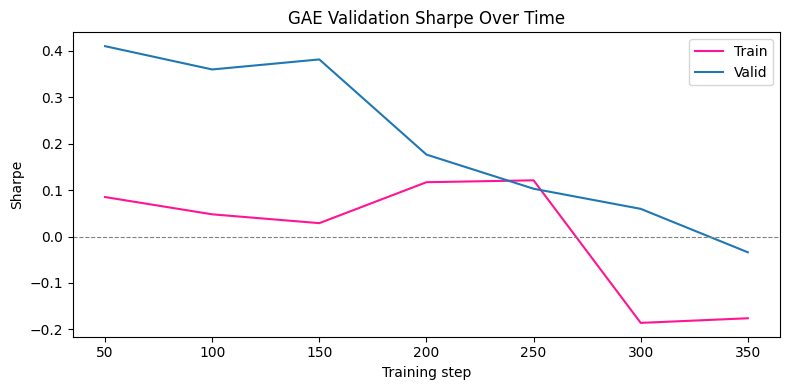

In [21]:
# Plot validation Sharpe trajectory
if history_ac and history_ac.get("eval_step"):
    hist_df = pd.DataFrame({
        "step": history_ac["eval_step"],
        "train_sharpe": history_ac.get("train_sharpe", []),
        "valid_sharpe": history_ac.get("valid_sharpe", []),
    })
    display(hist_df.tail())

    plt.figure(figsize=(8, 4))
    plt.plot(hist_df["step"], hist_df["train_sharpe"], label="Train", color='deeppink')
    plt.plot(hist_df["step"], hist_df["valid_sharpe"], label="Valid")
    plt.title("GAE Validation Sharpe Over Time")
    plt.xlabel("Training step")
    plt.ylabel("Sharpe")
    plt.axhline(0.0, color="grey", lw=0.8, ls="--")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No evaluation history recorded.")


In [18]:
# Compare GAE policy against baselines (deterministic evaluation)
from collections import OrderedDict

def _wrap_callable(fn):
    class _Tmp:
        def act(self, obs, deterministic=True):
            return float(fn(obs)), None, None
    return _Tmp()

comparisons = OrderedDict()
# if momentum_policy() and delta_hedge_policy(...) return plain callables,
# wrap them so they expose .act as evaluate_env expects.
#comparisons["momentum"] = _wrap_callable(momentum_policy())
comparisons["delta_hedge"] = _wrap_callable(delta_hedge_policy(lambda obs: obs[-1, 0]))
comparisons["spy_hold"] = _wrap_callable(lambda obs: env_tr.pos_limit)
comparisons["gae_policy"] = policy_ac
comparisons["vol_target"] = _wrap_callable(volatility_targeting(ann_vol_target=0.15))

for name, pol in list(comparisons.items()):
    if callable(pol) and not hasattr(pol, "act"):
        comparisons[name] = _wrap_callable(pol)

if 'baselines' in globals():
    for name, fn in baselines.items():
        comparisons[name] = _wrap_callable(fn)

rows = []
for name, pol in comparisons.items():
    metrics = {
        "train": evaluate_env(env_tr, pol, deterministic=True),
        "valid": evaluate_env(env_va, pol, deterministic=True),
        "test": evaluate_env(env_te, pol, deterministic=True),
    }
    for split, vals in metrics.items():
        rows.append({
            "policy": name,
            "split": split,
            "mean": vals["mean"],
            "std": vals["std"],
            "sharpe": vals["sharpe"],
            "steps": vals["steps"],
        })

results_df = pd.DataFrame(rows)
display(results_df.pivot(index="policy", columns="split", values="sharpe"))
results_df


split,test,train,valid
policy,,,
delta_hedge,-0.228435,-0.159253,-0.159194
gae_policy,0.375741,0.084910,0.409512
spy_hold,0.210909,0.375446,0.334204
vol_target,0.205420,0.300679,0.057240


,policy,split,mean,std,sharpe,steps
0,delta_hedge,train,-0.484462,48.291634,-0.159253,7823
1,delta_hedge,valid,-0.200660,20.009438,-0.159194,2474
2,delta_hedge,test,-0.563580,39.164543,-0.228435,7628
3,spy_hold,train,3.177574,134.353174,0.375446,7823
4,spy_hold,valid,1.460885,69.391263,0.334204,2474
5,spy_hold,test,1.222014,91.977324,0.210909,7628
6,gae_policy,train,0.068237,12.757416,0.084910,7823
7,gae_policy,valid,0.119867,4.646583,0.409512,2474
8,gae_policy,test,0.179495,7.583431,0.375741,7628
9,vol_target,train,1.004809,53.049466,0.300679,7823


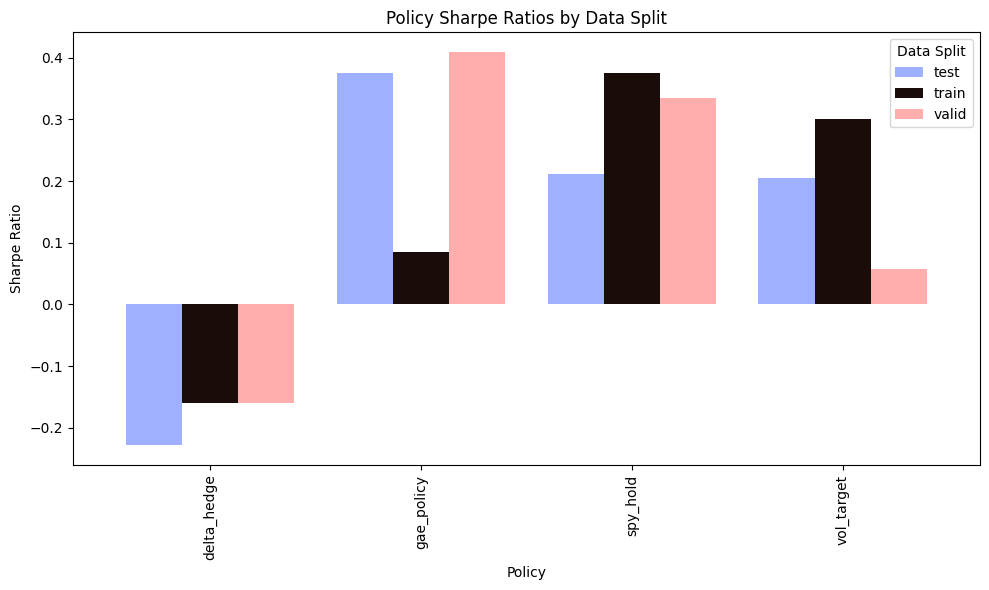

In [19]:
pivot = results_df.pivot(index="policy", columns="split", values="sharpe")

#Plotting the pivot table
pivot.plot(kind='bar', figsize=(10,6), width=0.8, colormap='berlin')
plt.title('Policy Sharpe Ratios by Data Split')
plt.ylabel('Sharpe Ratio')
plt.xlabel('Policy')
plt.legend(title='Data Split')
plt.tight_layout()
plt.show()


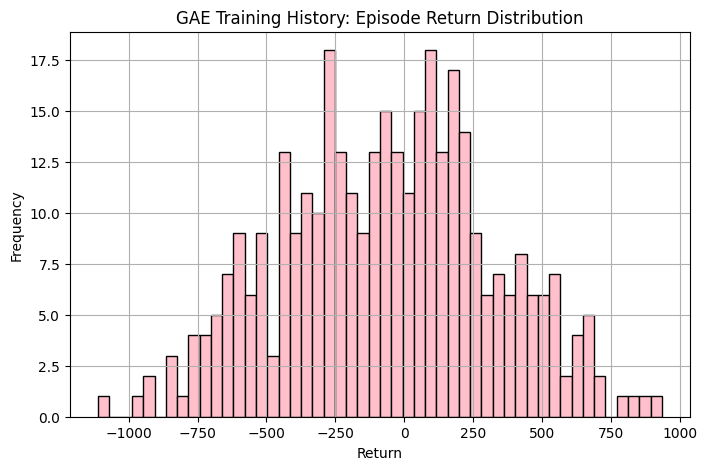

In [20]:
returns = pd.Series(history_ac['episode_return'])

returns.hist(bins=50, figsize=(8, 5), color='pink', edgecolor='black')
plt.title("GAE Training History: Episode Return Distribution")
plt.xlabel("Return")
plt.ylabel("Frequency")
plt.show()

# Evaluation

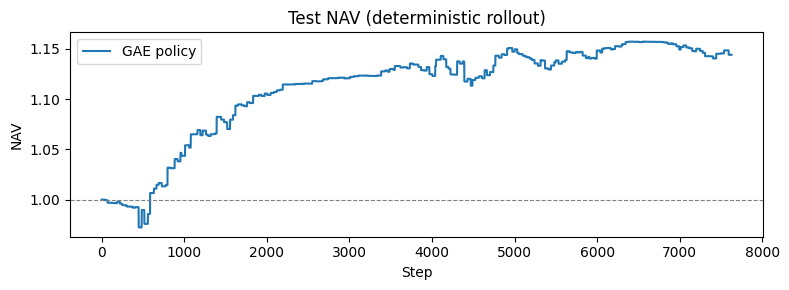

In [24]:
from rl_agent.trainer import deterministic_rewards

rewards_test = deterministic_rewards(env_te, policy_ac)
equity_curve = (1 + rewards_test / 1e4).cumprod()  # convert bp reward to NAV path

plt.figure(figsize=(8,3))
plt.plot(equity_curve, label="GAE policy")
plt.axhline(1.0, color="grey", lw=0.8, ls="--")
plt.title("Test NAV (deterministic rollout)")
plt.xlabel("Step")
plt.ylabel("NAV")
plt.legend()
plt.tight_layout()
plt.show()


In [25]:
rollout = env_te.rollout(lambda obs: policy_ac.act(obs, deterministic=True)[0])
pos = rollout["positions"]
turnover = np.abs(np.diff(pos)).sum()
print("Total turnover (|Δpos| sum):", turnover)


Total turnover (|Δpos| sum): 40.17815243755467
